# AI Waste Sorter

### Project Overview
In this project we try to build an AI model that can classify the kind of waste into 12 classes from images.

# CNN Model Building - Medium CNN

This project will do process of building various CNN models. We will build 3 CNN architecture with different complexity and compare the performance. For this notebook we will do medium CNN model architecture.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from datetime import datetime
import gc

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

if tf.config.list_physical_devices('GPU'):
    print("Using GPU")
    for gpu in tf.config.list_physical_devices('GPU'):
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("Using CPU")

2026-02-01 11:34:18.710810: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Using GPU


## 1. Configuration & Setup

In [2]:
BASE_DIR = Path.cwd()
PROCESSED_DIR = BASE_DIR / 'processed_data'
TRAIN_DIR = PROCESSED_DIR / 'train_balanced'
VAL_DIR = PROCESSED_DIR / 'val'
TEST_DIR = PROCESSED_DIR / 'test'
MODELS_DIR = BASE_DIR / 'models'
MODELS_DIR.mkdir(exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 100
NUM_CLASSES = 12

print(f"Image size: {IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")

Image size: (224, 224)
Batch size: 16
Epochs: 100


## 2. Data Generators with Augmentation

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"Train samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Test samples: {test_generator.samples}")

Found 8424 images belonging to 12 classes.
Found 1550 images belonging to 12 classes.
Found 1556 images belonging to 12 classes.
Train samples: 8424
Validation samples: 1550
Test samples: 1556


# 3. Build model architecture

For this simple CNN architecture we will build CNN with 4 convolutional blocks and ~5M parameters

In [4]:
def create_medium_cnn(input_shape=(224, 224, 3), num_classes=12):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.2),
        
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),
        
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),
        
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),
        
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ], name='MediumCNN')
    
    return model

model = create_medium_cnn()
model.summary()

I0000 00:00:1769920506.307905    3547 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1766 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "MediumCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 26,412,204 (100.75 MB)

 Trainable params: 26,409,708 (100.75 MB)

 Non-trainable params: 2,496 (9.75 KB)

## 6. Training Configuration

In [5]:
def get_callbacks(model_name):
    model_path = MODELS_DIR / f'{model_name}_best.keras'
    
    callbacks_list = [
        callbacks.ModelCheckpoint(
            filepath=str(model_path),
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        )
    ]
    
    return callbacks_list

## 7. Training model

In [6]:
print("Training Medium CNN")
print(f"Started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=get_callbacks('medium_cnn'),
    verbose=1
)

print(f"\nCompleted at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Training Medium CNN
Started at: 2026-02-01 11:35:07
Epoch 1/100


2026-02-01 11:35:12.145486: I external/local_xla/xla/service/service.cc:163] XLA service 0x737a60004610 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-01 11:35:12.145519: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2026-02-01 11:35:12.326361: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-01 11:35:13.093302: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91801
2026-02-01 11:35:16.663811: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 790.04MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-02-01 11:35:23.020

527/527 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.2278 - loss: 2.8257
Epoch 1: val_accuracy improved from None to 0.41419, saving model to /mnt/d/personal/AI and Machine Learning/waste sorter ai/models/medium_cnn_best.keras
527/527 ━━━━━━━━━━━━━━━━━━━━ 202s 341ms/step - accuracy: 0.2938 - loss: 2.4200 - val_accuracy: 0.4142 - val_loss: 1.7272 - learning_rate: 0.0010
Epoch 2/100
527/527 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.3898 - loss: 1.9046
Epoch 2: val_accuracy did not improve from 0.41419
527/527 ━━━━━━━━━━━━━━━━━━━━ 91s 173ms/step - accuracy: 0.4029 - loss: 1.8411 - val_accuracy: 0.4065 - val_loss: 2.0620 - learning_rate: 0.0010
Epoch 3/100
527/527 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.4498 - loss: 1.6784
Epoch 3: val_accuracy did not improve from 0.41419
527/527 ━━━━━━━━━━━━━━━━━━━━ 87s 165ms/step - accuracy: 0.4490 - loss: 1.6745 - val_accuracy: 0.3755 - val_loss: 2.1556 - learning_rate: 0.0010
Epoch 4/100
527/527 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step -

# 8. Training history plot

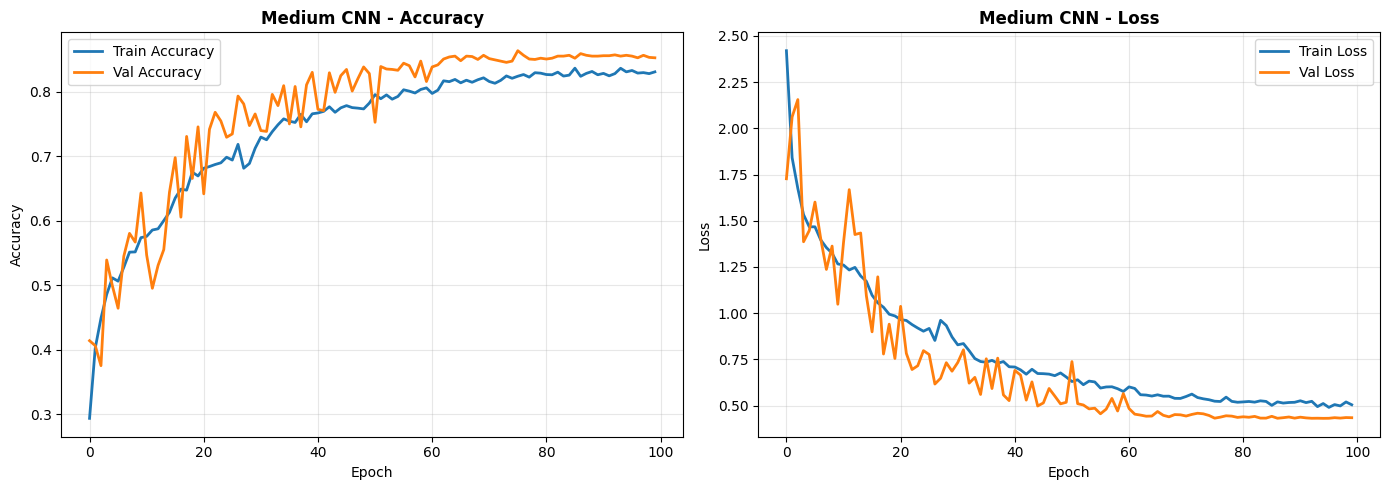

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0].set_title('Medium CNN - Accuracy', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[1].set_title('Medium CNN - Loss', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(MODELS_DIR / 'medium_cnn_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

# 9. Save model and classification report

In [8]:
model.load_weights(str(MODELS_DIR / 'medium_cnn_best.keras'))

test_generator.reset()
predictions = model.predict(test_generator, verbose=1)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

accuracy = accuracy_score(y_true, y_pred)

class_names = list(test_generator.class_indices.keys())
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)

print(f"\nMedium CNN Test Accuracy: {accuracy:.4f}")
print(f"\nClassification Report:")
print(report)

98/98 ━━━━━━━━━━━━━━━━━━━━ 22s 211ms/step

Medium CNN Test Accuracy: 0.8522

Classification Report:
              precision    recall  f1-score   support

     battery     0.8100    0.8526    0.8308        95
  biological     0.8235    0.8485    0.8358        99
 brown-glass     0.8548    0.8689    0.8618        61
   cardboard     0.9070    0.8667    0.8864        90
     clothes     0.9187    0.9118    0.9153       533
 green-glass     0.8955    0.9524    0.9231        63
       metal     0.7973    0.7662    0.7815        77
       paper     0.8455    0.8857    0.8651       105
     plastic     0.6915    0.7471    0.7182        87
       shoes     0.7978    0.7374    0.7664       198
       trash     0.9483    0.7857    0.8594        70
 white-glass     0.7253    0.8462    0.7811        78

    accuracy                         0.8522      1556
   macro avg     0.8346    0.8391    0.8354      1556
weighted avg     0.8545    0.8522    0.8524      1556



# 10. Confussion matrix plot

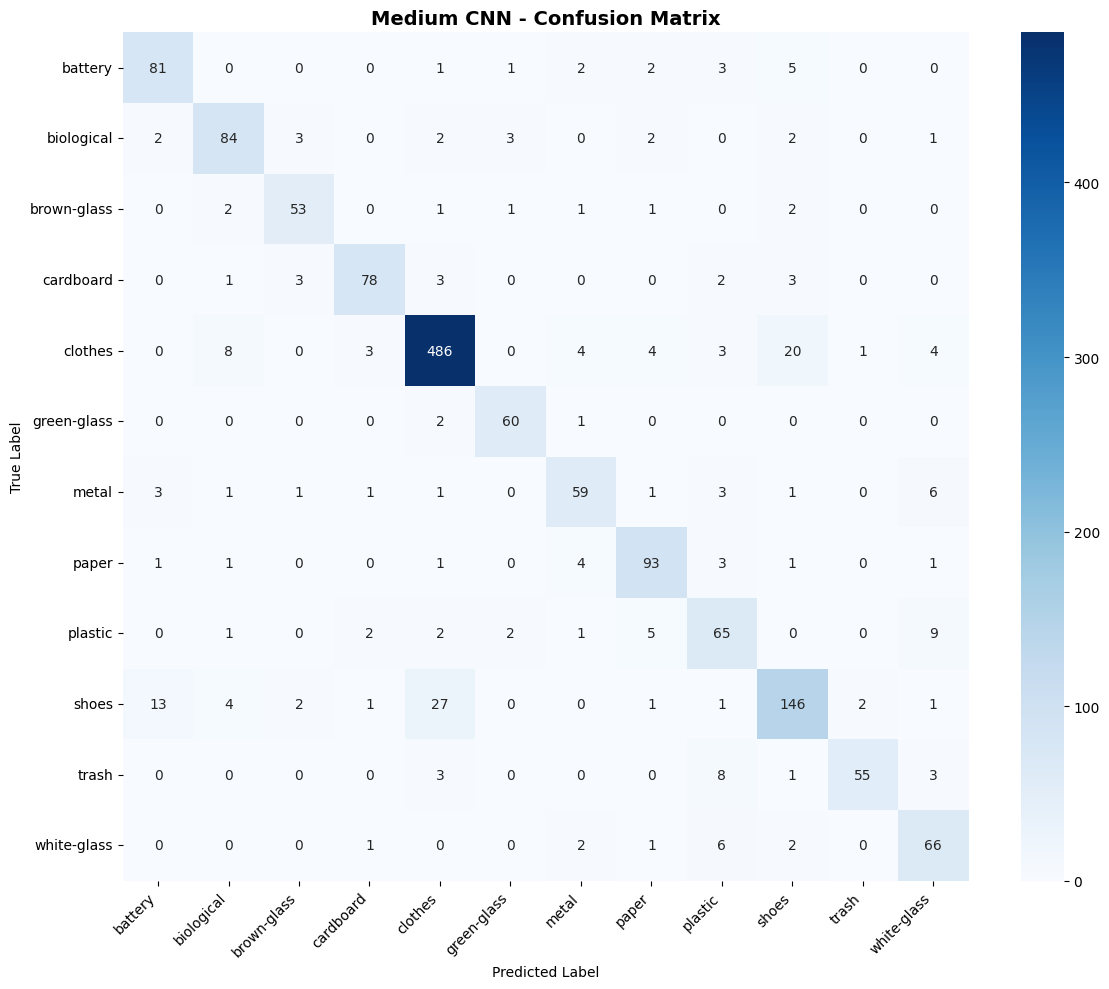

In [9]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Medium CNN - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'medium_cnn_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# 11. Summary

In [10]:
results = {
    'model_name': 'Medium CNN',
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'parameters': int(model.count_params()),
    'test_accuracy': float(accuracy),
    'best_val_accuracy': float(max(history.history['val_accuracy'])),
    'final_train_accuracy': float(history.history['accuracy'][-1]),
    'epochs_trained': len(history.history['accuracy']),
    'configuration': {
        'image_size': IMG_SIZE,
        'batch_size': BATCH_SIZE,
        'max_epochs': EPOCHS
    }
}

with open(MODELS_DIR / 'medium_cnn_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("Results saved to medium_cnn_results.json")
print(f"\nSummary:")
print(f"Parameters: {results['parameters']:,}")
print(f"Test Accuracy: {results['test_accuracy']:.4f}")
print(f"Best Val Accuracy: {results['best_val_accuracy']:.4f}")
print(f"Epochs Trained: {results['epochs_trained']}")

Results saved to medium_cnn_results.json

Summary:
Parameters: 26,412,204
Test Accuracy: 0.8522
Best Val Accuracy: 0.8639
Epochs Trained: 100
